In [5]:
import featuregraph as fg
import matplotlib.pyplot as plt

fault_number = 2
simulation_run = 10
signal = "reactor_pressure"


df = fg.datasets.eastman(
    fault_number=fault_number,
    simulation_run=simulation_run,
)

df["sample_index"] = df.index
df["time_hours"] = df["time_(h)"]
df["reactor_pressure_raw"] = df[signal]

numerical_atol = 1e-12

df["reactor_pressure_smooth"] = df['reactor_pressure'].rolling(50).max().rolling(50).mean().shift(-50)

df["reactor_pressure_rate"] = (
    df["reactor_pressure_smooth"].diff()
    / df["time_hours"].diff()
)

df["reactor_pressure_valid"] = (
    df["reactor_pressure_smooth"].notna()
    & df["reactor_pressure_rate"].notna()
)

valid = df["reactor_pressure_valid"]

eps = 0.0  # pressure units per hour

df["reactor_pressure_rising"] = (
    valid
    & df["reactor_pressure_rate"].gt(eps)
)

df["reactor_pressure_falling"] = (
    valid
    & df["reactor_pressure_rate"].lt(-eps)
)

df["reactor_pressure_inactive"] = (
    valid
    & df["reactor_pressure_rate"].abs().le(eps)
)

df['enter_reactor_pressure_rising'] = df['reactor_pressure_rising'].astype(int).diff().eq(1)
df['exit_reactor_pressure_rising'] = df['reactor_pressure_rising'].astype(int).diff().eq(-1)
df['exit_reactor_pressure_rising_id'] = df['exit_reactor_pressure_rising'].cumsum()

(<Figure size 1600x880 with 4 Axes>,
 array([<Axes: ylabel='reactor_pressure'>,
        <Axes: ylabel='reactor_pressure_smooth'>,
        <Axes: ylabel='exit_reactor_pressure_rising'>,
        <Axes: xlabel='Time', ylabel='exit_reactor_pressure_rising_id'>],
       dtype=object))

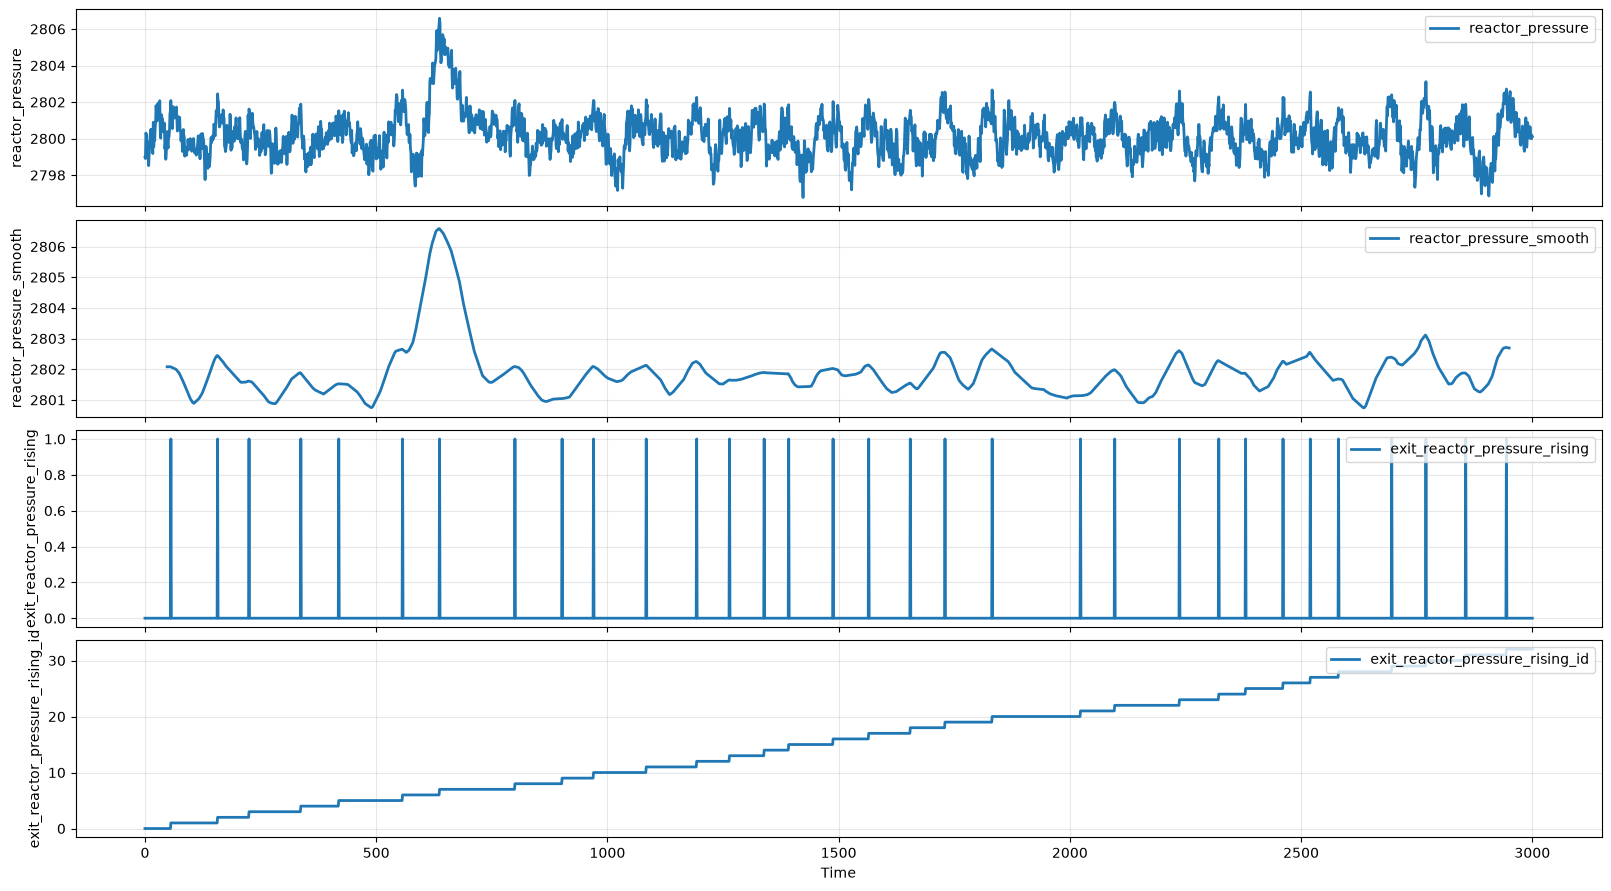

In [6]:
fg.plot(df, [['reactor_pressure'],
                              ['reactor_pressure_smooth'],
                            #   ['reactor_pressure_rising'],
                            #   ['reactor_pressure_falling'],
                            #   ['reactor_pressure_inactive'],
                            #   ['enter_reactor_pressure_rising'],
                              ['exit_reactor_pressure_rising'],
                              ['exit_reactor_pressure_rising_id']
                             ]
)


In [7]:
summarydf = df.groupby('exit_reactor_pressure_rising_id').agg(
    reactor_pressure_smooth_max=('reactor_pressure_smooth', 'max'),
    reactor_pressure_smooth_min=('reactor_pressure_smooth', 'min')
)

In [8]:
summarydf

,reactor_pressure_smooth_max,reactor_pressure_smooth_min
exit_reactor_pressure_rising_id,,
0,2802.081071,2802.079764
1,2802.446723,2800.890938
2,2802.439449,2801.572757
3,2801.885418,2800.876626
4,2801.870702,2801.192530
5,2802.654450,2800.748715
6,2806.584082,2802.549332
7,2806.578191,2801.570455
8,2802.085998,2800.950638
